In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
results = pd.read_csv('eval_results/EVAL_flagship_VAL/fold_0.csv')
results.head()

,slide_id,Y,Y_hat,p_0,p_1,p_2,p_3,p_4
0,PATH000009523,1,1,0.009490,0.913968,0.065981,0.010531,0.000029
1,PATH000009835,1,1,0.060582,0.890299,0.043540,0.005544,0.000036
2,PATH000009442,1,1,0.012773,0.895764,0.088174,0.003265,0.000024
3,PATH000009506,1,1,0.018266,0.965133,0.014581,0.002009,0.000011
4,PATH000009933,1,0,0.885257,0.107900,0.003800,0.003031,0.000011


In [43]:
thresholds = np.array([0.88, 0.88, 0., 0., 0.,])

probs = results[[f'p_{i}' for i in range(5)]]

met_thresh = probs[probs >= thresholds]

results.Y_hat = np.nanargmax(met_thresh, axis=1)

#results.Y_hat = np.argmax(results[[f'p_{i}' for i in range(5)]] >= thresholds, axis=1)

In [44]:
results[(results.Y_hat == 1) & (results.Y == 3)]

,slide_id,Y,Y_hat,p_0,p_1,p_2,p_3,p_4


In [45]:
cm = confusion_matrix(results.Y, results.Y_hat)
class_labels = ['Insufficient', 'Normal', 'Low-grade', 'High-grade', 'Cancer']

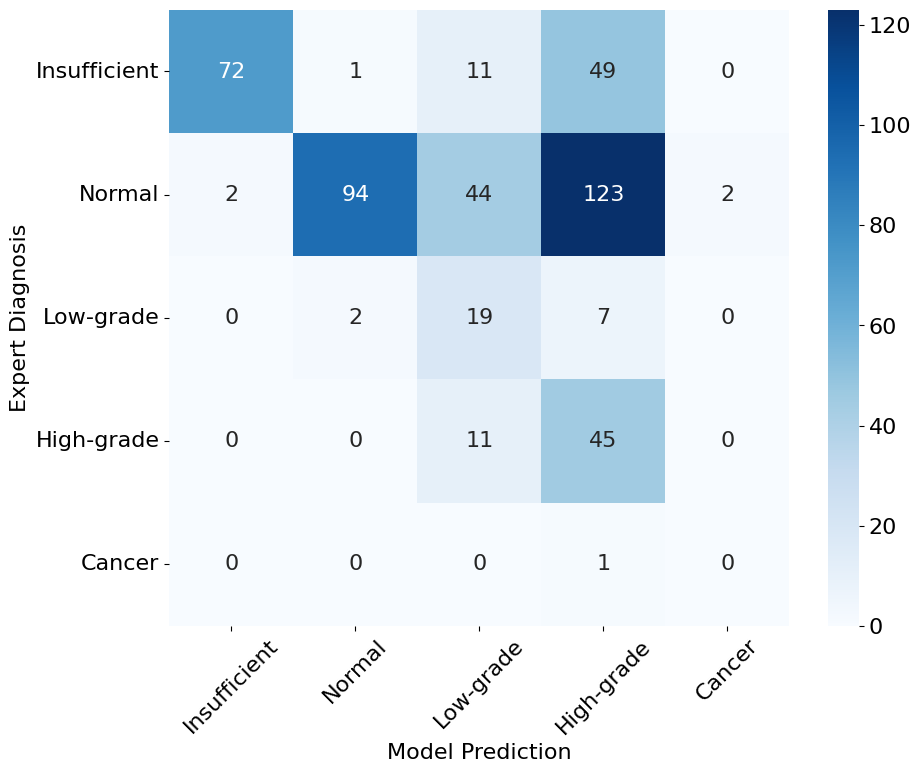

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.ylabel('Expert Diagnosis') # Changed from true to expert
plt.xlabel('Model Prediction')

# Rotate x-axis labels if they're long
plt.xticks(rotation=45, ha='center')
plt.yticks(rotation=0) #INCREASE FONT SIZE
plt.rc('font', size=16)

In [41]:
len(results[results.Y_hat < 2]) / len(results)

0.7929606625258799

In [42]:
float(((results.Y_hat < 2) & (results.Y > 2)).sum() / (results.Y > 2).sum())

0.10526315789473684

# Decision Curve

In [52]:
probs = results[[f'p_{i}' for i in range(5)]]

workload_saved = []
untreated = []

threshs =  np.arange(0.0, 1.0, 0.01)

for thresh in threshs:
    thresholds = np.array([thresh, thresh, 0., 0., 0.,])

    met_thresh = probs[probs >= thresholds]

    Y_hat = np.nanargmax(met_thresh, axis=1)

    workload_saved.append((Y_hat < 2).sum() / len(results))

    untreated.append(((Y_hat < 2) & (results.Y > 2)).sum() / (results.Y > 2).sum())


workload_saved =np.array(workload_saved) * 100
untreated = np.array(untreated) * 100

np.savetxt('tradeoff.csv', np.column_stack((workload_saved, untreated)), delimiter=',', header='Workload Saved (%), Cases requiring Treatment left Untreated (%)', comments='')

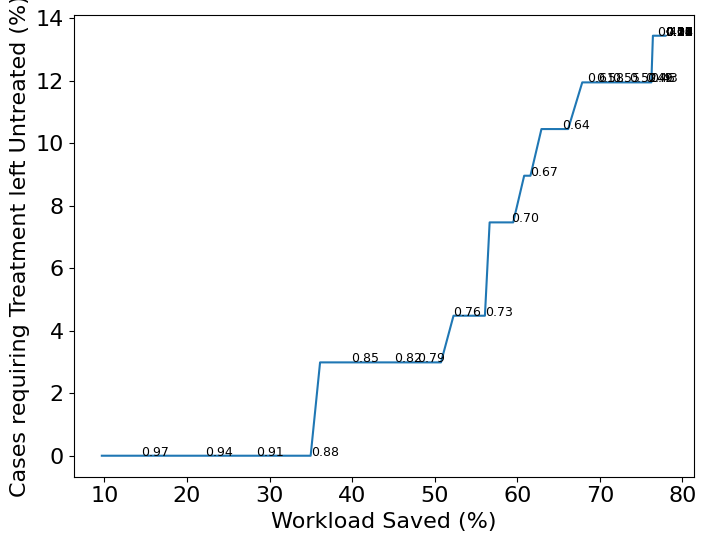

In [51]:
plt.figure(figsize=(8, 6))


# Plot the ROC curve
plt.plot(
    workload_saved, 
    untreated,
)
plt.xlabel('Workload Saved (%)')
plt.ylabel('Cases requiring Treatment left Untreated (%)')



for i in range(1, len(threshs), 3):
    # plt.text(x_coord, y_coord, text_label)
    plt.text(
        workload_saved[i],  # x-coordinate offset by +1 for horizontal spacing
        untreated[i],      # y-coordinate (no vertical offset)
        f"{threshs[i]:.2f}",
        fontsize=9,
    )

# Patient Level

In [3]:
labels = pd.read_csv('dataset_csv/pathology_full_subtyping.csv')

In [7]:
labels.case_id.nunique(), len(labels)

(3260, 5158)

In [8]:
labels.label.value_counts()

label
normal          2805
insufficient    1353
high_grade       643
low_grade        317
cancer            40
Name: count, dtype: int64

In [39]:
results = pd.merge(results, labels[['slide_id','case_id']], on="slide_id")

In [40]:
results.head()

,slide_id,Y,Y_hat,p_0,p_1,p_2,p_3,p_4,case_id
0,PATH000009523,1,1,0.009490,0.913968,0.065981,0.010531,0.000029,02-00283
1,PATH000009835,1,1,0.060582,0.890299,0.043540,0.005544,0.000036,02-00304
2,PATH000009442,1,1,0.012773,0.895764,0.088174,0.003265,0.000024,02-00417
3,PATH000009506,1,1,0.018266,0.965133,0.014581,0.002009,0.000011,02-00450
4,PATH000009933,1,0,0.885257,0.107900,0.003800,0.003031,0.000011,02-00482


In [21]:
patient_lvl = results.groupby('case_id')['Y_hat'].agg(Y_hat='max')
patient_lvl['Y'] = results.groupby('case_id')['Y'].agg('max')

In [22]:
cm = confusion_matrix(patient_lvl.Y, patient_lvl.Y_hat)

(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, 'Insufficient'),
  Text(0, 1.5, 'Normal'),
  Text(0, 2.5, 'Low Priority (Low grade)'),
  Text(0, 3.5, 'High Priority (High grade)'),
  Text(0, 4.5, 'Highest Priority (Cancer)')])

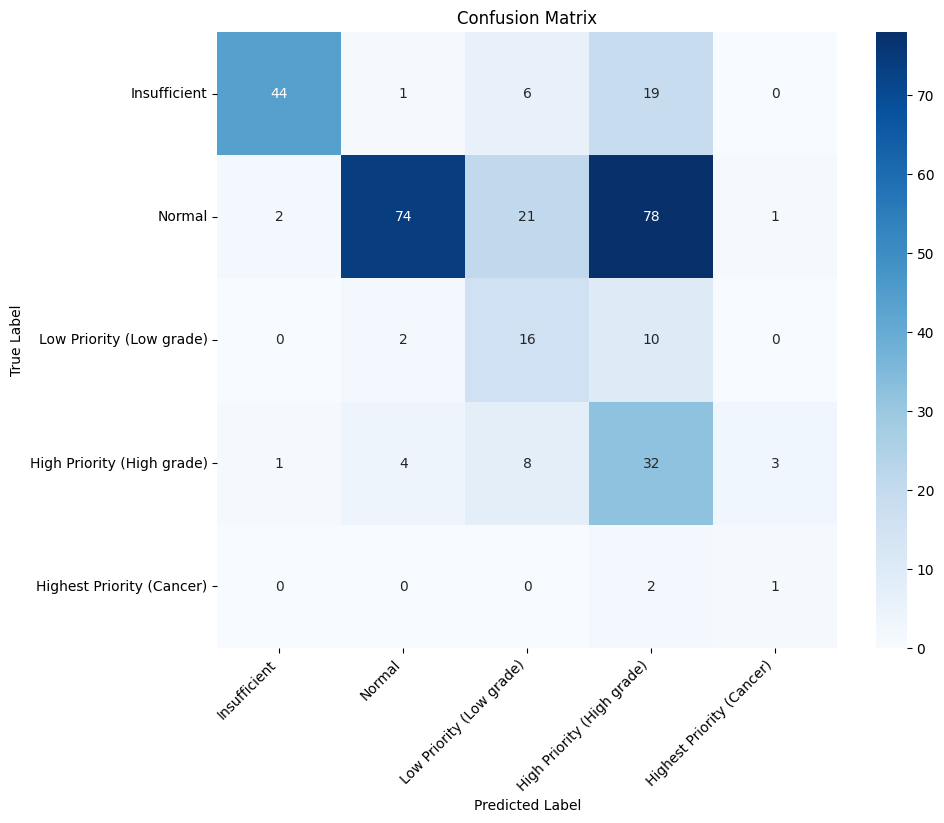

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Rotate x-axis labels if they're long
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

In [41]:
len(results)

526

In [25]:
results.case_id.nunique()

325

In [20]:
len(results[results.Y_hat < 2]) / len(results)

0.46387832699619774

In [15]:
raw_labels = pd.read_csv('labels.csv').rename(columns={'PATH_MASKED_IMG_ID': 'slide_id'})[
    ['PATH_SERVER_NAME', 'NCI_PID', 'slide_id', 'ENRL_AGE', 'SCRN_HPV', 'wst_bx_site', 'WST_EXPERT_DX', 'path_expert_img','PATH_EXPERT_DX_OTHER', 'PATH_EXPERT_DX_NOTES','PATH_LABEL_BIOPSY_TYPE']
]
raw_labels.slide_id = raw_labels.slide_id.str.replace('.SVS','')

merged = pd.merge(results, raw_labels, on='slide_id', how='left')

In [16]:
results = results[merged.PATH_LABEL_BIOPSY_TYPE != 'LEEP']